In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from utils import dataset_path
data_path = Path('data')
mail_paths = os.listdir(dataset_path)

In [2]:

count = 0
for mail_path in mail_paths:
    for path in os.listdir(dataset_path / Path(mail_path) / data_path):
        if path.endswith('.csv'):
            if count == 0:
                data = pd.read_csv(dataset_path / Path(mail_path) / data_path / path)
                count += 1
            else:
                data = pd.concat([data, pd.read_csv(dataset_path / Path(mail_path) / data_path / path)], ignore_index=True)
print("Total number of urls:", len(data))     

Total number of urls: 2686


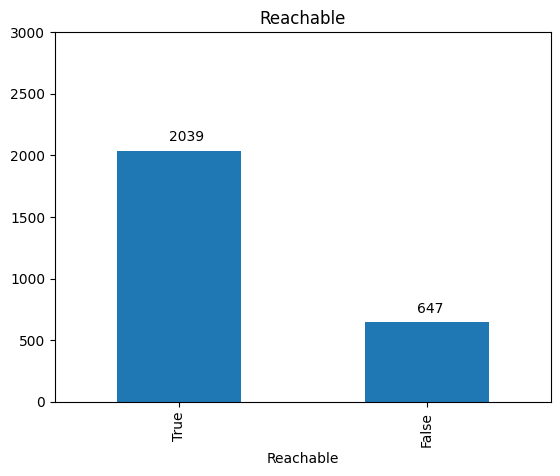

In [7]:
ax = plt.subplot()
values = data.value_counts('Reachable')
values.plot(kind='bar', title='Reachable',)
for i, v in enumerate(values):
    ax.annotate(str(v), xy=(i,v), xytext=(-7,7), textcoords='offset points')
plt.ylim(0, 3000)
plt.show()

(0.0, 3000.0)

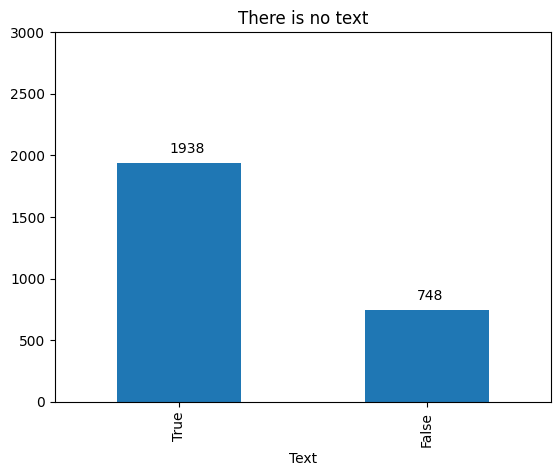

In [8]:
values = data.value_counts(data['Text'].notna())
ax = plt.subplot()
values.plot(kind='bar', title='There is no text')
for i, v in enumerate(values):
    ax.annotate(str(v), xy=(i,v), xytext=(-7,7), textcoords='offset points')
plt.ylim(0, 3000)

In [9]:
data

,Links,Reachable,Code,Text,Date
0,http://enujliwu.ru/wacajizo.pdf,False,"HTTPConnectionPool(host='enujliwu.ru', port=80...",NaN,"Wed, 18 May 2016 09:44:26 -0000"
1,http://ekykriqo.ru/vahilux.pdf,False,"HTTPConnectionPool(host='ekykriqo.ru', port=80...",NaN,"Wed, 18 May 2016 09:44:26 -0000"
2,https://www.routledge.com/Routledge-Internatio...,True,200,1st Edition\nRoutledge International Handbook ...,"Wed, 18 May 2016 09:44:26 -0000"
3,http://ityqwidy.ru/newubit.pdf,False,"HTTPConnectionPool(host='ityqwidy.ru', port=80...",NaN,"Wed, 18 May 2016 09:44:26 -0000"
4,http://iwomgogy.ru/jomefoler.pdf,False,"HTTPConnectionPool(host='iwomgogy.ru', port=80...",NaN,"Wed, 18 May 2016 09:44:26 -0000"
...,...,...,...,...,...
2681,https://www.towntopics.com/wordpress/2024/05/0...,False,"HTTPSConnectionPool(host='www.towntopics.com',...",NaN,"Wed, 01 May 2024 12:40:50 -0000"
2682,https://dailyguardian.com.ph/first-light-a-shi...,True,200,"By Christine Marie Lim Magpile, LPT\nEast Meet...","Wed, 01 May 2024 12:40:50 -0000"
2683,https://www.thisislocallondon.co.uk/news/24290...,True,200,‘The Hunger Games’ book review\nSuzanne Collin...,"Wed, 01 May 2024 12:40:50 -0000"
2684,https://www.celluloidz.com/psycho/decouverte-s...,True,200,Au gré des swipes sur votre application de ren...,"Wed, 01 May 2024 15:13:52 -0000"


In [ ]:
from langdetect import detect
languages = []
for t in data['Text'][data['Text'].notna()]:
    languages.append(detect(t))


In [ ]:
len(languages)

1270

In [ ]:
print("Number of different languages:", len(set(languages)))
print("languages:", set(languages))
print("Number of texts in french:", languages.count("fr"))
print("Number of texts in english:", languages.count("en"))

Number of different languages: 5
languages: {'en', 'ar', 'fr', 'ru', 'hi'}
Number of texts in french: 566
Number of texts in english: 700
